# 트랜스포머

## 입력 임베딩과 위치 인코딩

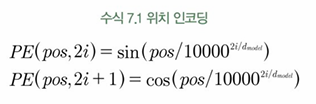

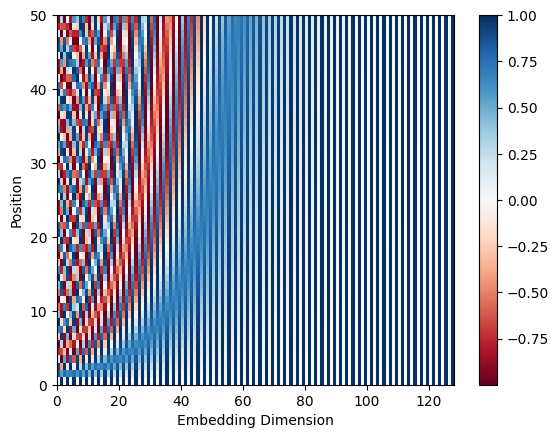

In [ ]:
# 위치 인코딩
import math
import torch
from torch import nn
from matplotlib import pyplot as plt

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1):
    # d_model: 임베딩 차원
    # max_len: 최대 시퀀스
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)

    position = torch.arange(max_len).unsqueeze(1) # 2차원 벡터 생성
    div_term = torch.exp( # 스케일링 인자 - 각 위치에 대한 주기적인 신호 생성
        torch.arange(0, d_model, 2) * (-math.log(10000.0)/d_model)
    )

    # 입력 차원과 같은 차원의 positional embedding 생성
    # pe = 위치 정보 -> 나중에 입력 시퀀스에 합산해야 함
    pe = torch.zeros(max_len, 1, d_model)
    pe[:, 0, 0::2] = torch.sin(position*div_term) # 홀수 - sin
    pe[:, 0, 1::2] = torch.cos(position*div_term) # 짝수 - cos
    ## pe 차원 - [50, 1, 128] ([최대 시퀀스, 1, 입력 임베딩 차원])
    self.register_buffer("pe", pe) # 모델이 매개변수를 갱신하지 않게 함

  def forward(self, x):
    x = x + self.pe[:x.size(0)] # 위치 정보 합산
    return self.dropout(x)

encoding = PositionalEncoding(d_model=128, max_len=50)

plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap="RdBu")
plt.xlabel("Embedding Dimension")
plt.xlim((0, 128))
plt.ylabel("Position")
plt.colorbar()
plt.show()

=> 위치별 임베딩 차원이 주기적인 값으로 구성됨

# 트랜스포머 모델 실습

영어-독일어 번역 모델 구성 - Multi30k 데이터셋 사용

In [9]:
!pip install torchdata torchtext portalocker

  Using cached portalocker-3.2.0-py3-none-any.whl.metadata (8.7 kB)
Using cached portalocker-3.2.0-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchdata]


In [14]:
!python --version

Python 3.11.14


In [15]:
import torch
import torchtext
torch.__version__
print(torchtext.__version__)

OSError: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchtext/lib/libtorchtext.so

In [11]:
from torchtext.datasets import Multi30k

OSError: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchtext/lib/libtorchtext.so

In [ ]:
# 데이터셋 다운로드 및 전처리
from torchtext.datasets import Multi30k
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator


def generate_tokens(text_iter, language):
    language_index = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}

    for text in text_iter:
        yield token_transform[language](text[language_index[language]])


SRC_LANGUAGE = "de"
TGT_LANGUAGE = "en"
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

token_transform = {
    SRC_LANGUAGE: get_tokenizer("spacy", language="de_core_news_sm"),
    TGT_LANGUAGE: get_tokenizer("spacy", language="en_core_web_sm"),
}
print("Token Transform:")
print(token_transform)

vocab_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    train_iter = Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    vocab_transform[language] = build_vocab_from_iterator(
        generate_tokens(train_iter, language),
        min_freq=1,
        specials=special_symbols,
        special_first=True,
    )

for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language].set_default_index(UNK_IDX)

print("Vocab Transform:")
print(vocab_transform)

In [ ]:
# 트랜스포머 모델 구성
import math
import torch
from torch import nn


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)

class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        num_encoder_layers,
        num_decoder_layers,
        emb_size,
        max_len,
        nhead,
        src_vocab_size,
        tgt_vocab_size,
        dim_feedforward,
        dropout=0.1,
    ):
        super().__init__()
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(
            d_model=emb_size, max_len=max_len, dropout=dropout
        )
        self.transformer = nn.Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(
        self,
        src,
        trg,
        src_mask,
        tgt_mask,
        src_padding_mask,
        tgt_padding_mask,
        memory_key_padding_mask,
    ):
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        outs = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            memory_mask=None,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(
            self.positional_encoding(self.src_tok_emb(src)), src_mask
        )

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(
            self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
        )

In [ ]:
# 트랜스포머 모델 구조
from torch import optim

BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),
    dim_feedforward=512,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)

In [ ]:
# 배치 데이터 생성
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence


def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

def input_transform(token_ids):
    return torch.cat(
        (torch.tensor([BOS_IDX]), torch.tensor(token_ids), torch.tensor([EOS_IDX]))
    )

def collator(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))

    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch


text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    text_transform[language] = sequential_transforms(
        token_transform[language], vocab_transform[language], input_transform
    )

data_iter = Multi30k(split="valid", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)
source_tensor, target_tensor = next(iter(dataloader))

print("(source, target):")
print(next(iter(data_iter)))

print("source_batch:", source_tensor.shape)
print(source_tensor)

print("target_batch:", target_tensor.shape)
print(target_tensor)

In [ ]:
# 어텐션 마스크 생성
def generate_square_subsequent_mask(s):
    mask = (torch.triu(torch.ones((s, s), device=DEVICE)) == 1).transpose(0, 1)
    mask = (
        mask.float()
        .masked_fill(mask == 0, float("-inf"))
        .masked_fill(mask == 1, float(0.0))
    )
    return mask


def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask


target_input = target_tensor[:-1, :]
target_out = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor, target_input
)

print("source_mask:", source_mask.shape)
print(source_mask)
print("target_mask:", target_mask.shape)
print(target_mask)
print("source_padding_mask:", source_padding_mask.shape)
print(source_padding_mask)
print("target_padding_mask:", target_padding_mask.shape)
print(target_padding_mask)

In [ ]:
# 모델 학습 및 평가
def run(model, optimizer, criterion, split):
    model.train() if split == "train" else model.eval()
    data_iter = Multi30k(split=split, language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)

    losses = 0
    for source_batch, target_batch in dataloader:
        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        target_input = target_batch[:-1, :]
        target_output = target_batch[1:, :]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(
            source_batch, target_input
        )

        logits = model(
            src=source_batch,
            trg=target_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )

        optimizer.zero_grad()
        loss = criterion(logits.reshape(-1, logits.shape[-1]), target_output.reshape(-1))
        if split == "train":
            loss.backward()
            optimizer.step()
        losses += loss.item()

    return losses / len(list(dataloader))


for epoch in range(5):
    train_loss = run(model, optimizer, criterion, "train")
    val_loss = run(model, optimizer, criterion, "valid")
    print(f"Epoch: {epoch+1}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")

In [ ]:
# 트랜스포머 모델 번역 결과
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)

    memory = model.encode(source_tensor, source_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)
    for i in range(max_len - 1):
        memory = memory.to(DEVICE)
        target_mask = generate_square_subsequent_mask(ys.size(0))
        target_mask = target_mask.type(torch.bool).to(DEVICE)

        out = model.decode(ys, memory, target_mask)
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(source_tensor.data).fill_(next_word)], dim=0
        )
        if next_word == EOS_IDX:
            break
    return ys


def translate(model, source_sentence):
    model.eval()
    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)
    num_tokens = source_tensor.shape[0]
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model, source_tensor, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX
    ).flatten()
    output = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))[1:-1]
    return " ".join(output)


output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu .")
output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude .")
print(output_oov)
print(output)

# GPT

허깅 페이스 트랜스포머스 라이브러리 GPT2LMHeadModel 로 문장 생성하기

## GPT-2 모델 구조

In [ ]:
from transformers import GPT2LMHeadModel

# 사전 학습된 GPT-2 모델 불러오기
model = GPT2LMHeadModel.from_pretrained(pretrained_model_name_or_path="gpt2")
## pretrained_model_name_or_path: 불러오려는 사전 학습된 모델

for main_name, main_module in model.named_children():
  print(main_name)
  for sub_name, sub_module in main_module.named_children():
    print("└", sub_name)
    for ssub_name, ssub_module in sub_module.named_children():
      print("| └", ssub_name)
      for sssub_name, sssub_module in ssub_module.named_children():
        print("| | └", sssub_name)

transformer
└ wte
└ wpe
└ drop
└ h
| └ 0
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 1
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 2
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 3
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 4
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 5
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 6
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 7
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 8
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 9
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 10
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
| └ 11
| | └ ln_1
| | └ attn
| | └ ln_2
| | └ mlp
└ ln_f
lm_head


gpt2: 12개의 디코더 계층을 사용하는 간소화 모델

(48개 디코더 사용 모델은 gpt2-xl로 불러올 수 있음)

- wte: 단어 토큰 임베딩
- wpe: 단어 위치 임베딩
- drop: dropout
- h: 트랜스포머 디코더 계층
- lm_head: 선형 임베딩 및 언어 모델

In [ ]:
# GPT-2를 이용한 문장 생성
from transformers import pipeline

generator = pipeline(task="text-generation", model='gpt2')
## 입력된 작업에 모델로 적합한 파이프라인 구축
## pipeline: 다양한 작업에 대한 전처리, 모델 아키텍처, 후처리 각각 처리하는 함수
outputs=generator(
    text_inputs="Machine learning is",
    max_length=20,
    num_return_sequences=3,
    pad_token_id=generator.tokenizer.eos_token_id # end of sentence
)

print(outputs)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Machine learning is also a lot more complex than it used to be. For example, there was a time when the goal of learning to read was to have no memory. Now, if you read a book in the morning, you can't remember what you wrote about.\n\nSo it's not so much that you have to be a genius to learn to read, it's that you have to learn to read. So if you can't read, it's because you're reading.\n\nLearning to read is going to take a while. It will take a lot of time. And at some point there will be a point where you have to go through a lot of different things to learn to read. I mean, that's a lot of time. There is something about reading that's so amazing that it's hard to stop and then you have to learn to read, and now you can go back and read and find out what happened to the book we all read.\n\nThis is the kind of information that you need to learn to read. It's not that you can't read it, it's that you need to learn to read. What you need to learn to read is to lea

[{'generated_text': "Machine learning is also a lot more complex than it used to be. For example, there was a time when the goal of learning to read was to have no memory. Now, if you read a book in the morning, you can't remember what you wrote about.\n\nSo it's not so much that you have to be a genius to learn to read, it's that you have to learn to read. So if you can't read, it's because you're reading.\n\nLearning to read is going to take a while. It will take a lot of time. And at some point there will be a point where you have to go through a lot of different things to learn to read. I mean, that's a lot of time. There is something about reading that's so amazing that it's hard to stop and then you have to learn to read, and now you can go back and read and find out what happened to the book we all read.\n\nThis is the kind of information that you need to learn to read. It's not that you can't read it, it's that you need to learn to read. What you need to learn to read is to learn to read, and learning to read is that.\n\nKATHLEEN"},

 {'generated_text': 'Machine learning is being used in this sector to improve how we predict future behavior.\n\nThe future is where the future itself is moving. The next step is to identify the future. These predictions are likely to be very difficult to predict, because the future is not always clear to the human eye or the machine.\n\nIn that sense, the future of AI is an important part of the AI development process. The next stage is not to build an AI system that is both intelligent and ready for human use. Rather, the next stage is to develop and refine the AI system.\n\nThe next stage will be to develop and refine the AI system to meet the needs of the human user. These are the areas where the AI system will be a good fit for human use.\n\nHow does your AI system compare with the human?\n\nThe human algorithm is more accurate and more accurate.\n\nThe human algorithm is not as complex as the AI system. It is much more complex and better suited for human use.\n\nThe human algorithm is more accurate and better suited to human use.\n\nThe human algorithm is much more accurate and better suited to human use.\n\nThe human algorithm is more accurate and better suited to human use.\n\nThe human algorithm is'},

 {'generated_text': 'Machine learning is a powerful tool for learning new data and how we can improve it. We\'ve been working on this for the past year, and it\'s been good for us. We\'ve been very lucky to be able to spend a lot of time with these kids.\n\n"It\'s great to see the growth of our research. It\'s great to see the progress that\'s being made with our tools. It\'s great to see our product is getting better. We\'re learning a lot. It\'s more exciting to see what we can do to help. We\'re hoping to have a new product come out in about five years."\n\nDr. Muthi: How would you describe the process of developing your new product?\n\nMr. Moore: We\'re looking to make it as easy as possible to use the data to improve our products. And we\'re looking forward to seeing you in the lab as soon as possible.\n\nDr. Muthi: Will it be a product that you use every day, or will it be a product that you use for a while, or are you going to switch to someone else\'s product to learn more about the data you have accumulated over the years?\n\nMr. Moore: I think we\'re going to work on'}]

## CoLA 데이터셋 실습

In [1]:
!python --version

Python 3.12.12


In [2]:
# 기존 Python 제거 (강제)
!sudo apt-get update -y
!sudo apt-get install python3.11 python3.11-distutils python3.11-venv -y

# 기본 python3 링크 변경
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.12 1
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.11 2
!sudo update-alternatives --config python3

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,151 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Pa

In [3]:
# python3.11용 pip 설치
!curl https://bootstrap.pypa.io/get-pip.py -o get-pip.py
!python3 get-pip.py

# pip 업그레이드
!python3 -m pip install --upgrade pip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2131k  100 2131k    0     0  1530k      0  0:00:01  0:00:01 --:--:-- 1531k
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 8.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pip]


In [6]:
# 기존 torch/torchtext 제거
!python3 -m pip uninstall -y torch torchtext

!python3 -m pip install torch==2.3.1 torchtext==0.18.0

  Using cached torchtext-0.18.0-cp311-cp311-manylinux1_x86_64.whl.metadata (7.9 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2025.10.0-py3-none-any.whl.metadata (10 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-n

In [8]:
!python --version

import torch
print(torch.__version__)
torchtext.__version__

Python 3.11.14
2.9.1+cu128


NameError: name 'torchtext' is not defined

In [11]:
# CoLA(The Corpus of Linguistic Acceptability) 데이터셋 로드
import torch
# from torchtext.datasets import CoLA
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

# collator: 여러 설정 작업 수행
def collator(batch, tokenizer, device):
  # source, labels, texts = zip(*batch)
  texts = [item["sentence"] for item in batch]
  labels = [int(item["label"]) for item in batch]

  tokenized = tokenizer(
      texts,
      padding="longest",   # 패딩 - 가장 긴 시퀀스에 패딩 적용
      truncation=True,     # 절사 - 최대 길이 초과 시 시퀀스 자를지
      return_tensors='pt', # 반환 형식 설정 - Tensor
  )
  input_ids = tokenized["input_ids"].to(device)
  attention_mask = tokenized["attention_mask"].to(device)
  labels = torch.tensor(labels, dtype=torch.long).to(device)

  # 토큰 ID, 어텐션 마스크 반환
  return input_ids, attention_mask, labels

# train_data = list(CoLA(split="train"))
# valid_data = list(CoLA(split="dev"))
# test_data = list(CoLA(split="test"))

# 허깅 트랜스포머 데이터셋 이용
dataset = load_dataset("glue", "cola")

# CoLA -> train, dev, test 데이터셋으로 구성됨
train_data = dataset['train'] # 학습
valid_data = dataset['validation'].select(range(500)) # 검증
test_data = dataset['validation'].select(range(500, len(datset['validation']))) # 검증
# test_data = dataset['test'] # 평가

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token # gpt-2는 패딩 토큰이 따로 없음

epochs=3
batch_size=16
device="cuda" if torch.cuda.is_available() else "cpu"

# 데이터로더 설정
train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    collate_fn=lambda x: collator(x, tokenizer, device),
    shuffle=True,
)
valid_dataloader = DataLoader(
    valid_data, batch_size=batch_size, collate_fn=lambda x: collator(x, tokenizer, device)
)
test_dataloader = DataLoader(
    test_data, batch_size=batch_size, collate_fn=lambda x: collator(x, tokenizer, device)
)

print("Train Dataset Length: ", len(train_data))
print("Valid Dataset Length: ", len(valid_data))
print("Test Dataset Length: ", len(test_data))

KeyboardInterrupt: 

In [ ]:
print(train_data[0])
print(valid_data[0])
print(test_data[0]) # 얘 label은 어떡하지

In [ ]:
# GPT-2 모델 설정
from torch import optim
from transformers import GPT2ForSequenceClassification # 문장 분류 모델 클래스

model = GPT2ForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="gpt2",
    num_labels=2 # CoLA 데이터셋은 올바른 문장과 올바르지 않은 문장이 태깅되어 있음
).to(device)
model.config.pad_token_id = model.config.eos_token_id # 패딩 토큰 설정
optimizer = optim.Adam(model.parameters(), lr=5e-5)

사전학습된 gpt2 모델이 다운로드됨

In [ ]:
# GPT-2 모델 학습 및 검증
import numpy as np
from torch import nn

def calc_accuracy(preds, labels):
  pred_flat = np.argmax(preds, axis=1).flatten()
  labels_flat = labels.flatten()
  return np.sum(pred_flat == labels_flat) / len(labels_flat) # 정확도 반환

def train(model, optimizer, dataloader):
  model.train()
  train_loss = 0.0

  for input_ids, attention_mask, labels in dataloader:
    outputs = model( # 데이터 -> 모델
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss # 학습 시 내부적으로 손실 계산 및 반환
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss = train_loss / len(dataloader)
  return train_loss

def evaluation(model, dataloader):
  with torch.no_grad():
    model.eval()
    criterion = nn.CrossEntropyLoss()
    val_loss, val_accuracy = 0.0, 0.0

    for input_ids, attention_mask, labels in dataloader:
      outputs = model( # 평가용 데이터 -> 모델
          input_ids=input_ids,
          attention_mask=attention_mask,
          labels=labels
      )
      logits=outputs.logits # 확률

      loss = criterion(logits, labels)
      logits=logits.detach().cpu().numpy()
      label_ids=labels.to("cpu").numpy()
      accuracy = calc_accuracy(logits, label_ids) # 확률, 레이블로 손실 계산

      val_loss+=loss
      val_accuracy+=accuracy

  val_loss = val_loss / len(dataloader)
  val_accuracy = val_accuracy / len(dataloader)
  return val_loss, val_accuracy

best_loss = 10000
for epoch in range(epochs):
  train_loss = train(model, optimizer, train_dataloader)
  val_loss, val_accuracy = evaluation(model, valid_dataloader)
  print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val Accuracy {val_accuracy:.4f}")

  if val_loss < best_loss:
    best_loss = val_loss
    torch.save(model.state_dict(), "/content/drive/MyDrive/euron/datasets/Week12/GPT2ForSequenceClassification.pt")
    print("Saved the model weights")

In [ ]:
# 모델 평가
model = GPT2ForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="gpt2",
    num_labels=2
).to(device)
model.config.pad_token_id=model.config.eos_token_id
model.load_state_dict(torch.load("/content/drive/MyDrive/euron/datasets/Week12/GPT2ForSequenceClassification.pt"),)

test_loss, test_accuracy = evaluation(model, test_dataloader)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")